# Predicting New York Housing Prices — Multiple Linear Regression

**Target:** `PRICE` (we model the log of price)

**Core three features:** `BEDS`, `BATH`, `PROPERTYSQFT`

**Extra engineered features (to make the model more accurate):**
`LOG_SQFT` (log of size), `BATH_PER_BED` (bathrooms per bedroom),
`BOROUGH` (location), and `PROPERTY_TYPE`.

The notebook follows the six assignment questions in order.

## 1. Understanding the data

First we load the data and look at it to understand what we are working with.

In [1]:
# STEP 1: Import the libraries we need
import pandas as pd               # for working with tables of data
import numpy as np                # for maths (like log)
import matplotlib.pyplot as plt   # for charts
import seaborn as sns             # for nicer charts

%matplotlib inline

# Load the dataset (the CSV file must be in the same folder as this notebook)
df = pd.read_csv("NYHousing.csv")

# Show the first 5 rows
df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [2]:
# Check how many rows and columns there are
print("Rows and columns:", df.shape)

# Check the column names, data types and counts
df.info()

Rows and columns: (4801, 17)
<class 'pandas.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   str    
 1   TYPE                         4801 non-null   str    
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   str    
 7   STATE                        4801 non-null   str    
 8   MAIN_ADDRESS                 4801 non-null   str    
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   str    
 10  LOCALITY                     4801 non-null   str    
 11  SUBLOCALITY                  4801 non-null   str    
 12  STREET_NAME                  4801 non-null   str    
 13  

In [3]:
# Basic statistics (average, min, max, etc.) for the number columns
df.describe()

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.801000e+03,4801.000000,4801.000000,4801.000000,4801.000000,4801.000000
mean,2.356940e+06,3.356801,2.373861,2184.207862,40.714227,-73.941601
std,3.135525e+07,2.602315,1.946962,2377.140894,0.087676,0.101082
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.639375,-73.987143
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726749,-73.949189
75%,1.495000e+06,4.000000,3.000000,2184.207862,40.771923,-73.870638
max,2.147484e+09,50.000000,50.000000,65535.000000,40.912729,-73.702450


In [4]:
# Check for data problems

# Are there missing values?
print("Total missing values:", df.isnull().sum().sum())

# Are there duplicate rows?
print("Duplicate rows:", df.duplicated().sum())

# Some values are clearly fake placeholders, not real data:
print("Fake PRICE (2,147,483,647):", (df["PRICE"] == 2147483647).sum())
print("Fake SQFT (65,535):", (df["PROPERTYSQFT"] == 65535).sum())
print("Fake SQFT (mean value 2184.21):", (df["PROPERTYSQFT"].round(2) == 2184.21).sum())

Total missing values: 0
Duplicate rows: 214
Fake PRICE (2,147,483,647): 1
Fake SQFT (65,535): 1
Fake SQFT (mean value 2184.21): 1621


**What we learned:**
- 4,801 rows and 17 columns, one property per row.
- No empty cells, but some values are fake placeholders (we remove these in Step 3).
- About 1,621 rows have the square footage filled in with the average value (also fake).
- There are 214 duplicate rows.
- Price is very skewed: most homes are cheap, a few are extremely expensive.

## 2. Initial visualizations of the original data

We make some charts to see the data before we change anything.

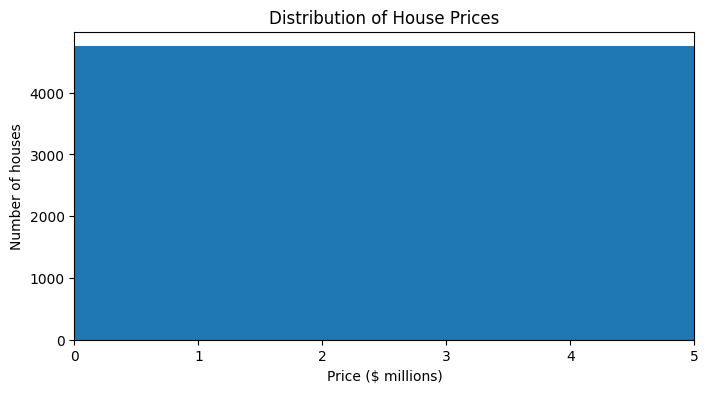

In [5]:
# Chart 1: how prices are spread out (in millions of dollars)
plt.figure(figsize=(8, 4))
plt.hist(df["PRICE"] / 1000000, bins=100)
plt.xlim(0, 5)   # only show up to $5m so the chart is readable
plt.title("Distribution of House Prices")
plt.xlabel("Price ($ millions)")
plt.ylabel("Number of houses")
plt.show()

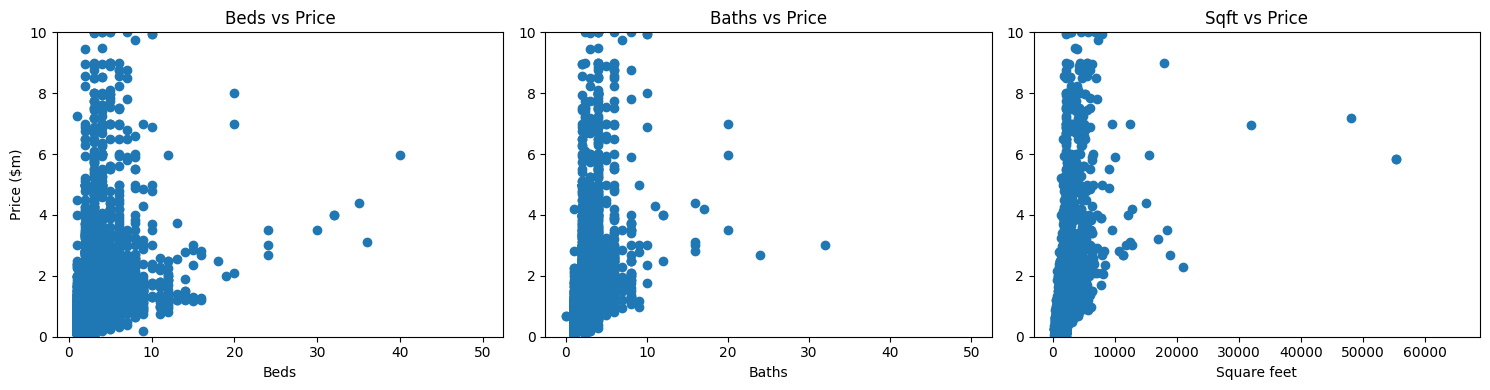

In [6]:
# Chart 2: each feature against price, to see if there is a relationship
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(df["BEDS"], df["PRICE"] / 1000000)
plt.title("Beds vs Price"); plt.xlabel("Beds"); plt.ylabel("Price ($m)"); plt.ylim(0, 10)

plt.subplot(1, 3, 2)
plt.scatter(df["BATH"], df["PRICE"] / 1000000)
plt.title("Baths vs Price"); plt.xlabel("Baths"); plt.ylim(0, 10)

plt.subplot(1, 3, 3)
plt.scatter(df["PROPERTYSQFT"], df["PRICE"] / 1000000)
plt.title("Sqft vs Price"); plt.xlabel("Square feet"); plt.ylim(0, 10)

plt.tight_layout()
plt.show()

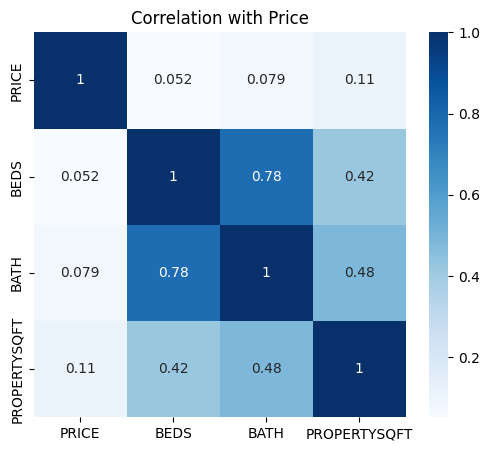

In [7]:
# Chart 3: correlation heatmap (how strongly features relate to price)
plt.figure(figsize=(6, 5))
sns.heatmap(df[["PRICE", "BEDS", "BATH", "PROPERTYSQFT"]].corr(), annot=True, cmap="Blues")
plt.title("Correlation with Price")
plt.show()

The charts show price is very skewed, and that bathrooms and square footage have the
clearest link with price.

## 3. Data preparation and feature engineering

Now we clean the data and create the extra features that will improve the model.

In [8]:
# Make a copy so we keep the original data safe
data = df.copy()

# --- Cleaning ---
# Remove duplicate rows
data = data.drop_duplicates()

# Remove the fake placeholder values we found in Step 1
data = data[data["PRICE"] != 2147483647]
data = data[data["PROPERTYSQFT"] != 65535]
data = data[data["PROPERTYSQFT"].round(2) != 2184.21]

print("Rows left after cleaning:", len(data))

Rows left after cleaning: 3046


In [9]:
# --- Feature engineering: create new useful columns ---

# 1) Take the log of price and size. They are very skewed, and log makes them
#    more even, which helps a linear model a lot.
data["LOG_PRICE"] = np.log(data["PRICE"])
data["LOG_SQFT"] = np.log(data["PROPERTYSQFT"])

# 2) Bathrooms per bedroom (a simple measure of how "luxury" a home is)
data["BATH_PER_BED"] = data["BATH"] / data["BEDS"].replace(0, 1)  # the replace avoids dividing by 0

data[["PRICE", "LOG_PRICE", "PROPERTYSQFT", "LOG_SQFT", "BATH_PER_BED"]].head()

,PRICE,LOG_PRICE,PROPERTYSQFT,LOG_SQFT,BATH_PER_BED
0,315000,12.660328,1400.0,7.244228,1.000000
1,195000000,19.088510,17545.0,9.772524,1.428571
2,260000,12.468437,2015.0,7.608374,0.500000
3,69000,11.141862,445.0,6.098074,0.333333
4,55000000,17.822844,14175.0,9.559235,0.339123


In [10]:
# 3) Clean up the location column.
#    The same borough is written in different ways, so we group them together.
borough_map = {
    "New York": "Manhattan", "New York County": "Manhattan", "Manhattan": "Manhattan",
    "Kings County": "Brooklyn", "Brooklyn": "Brooklyn", "Coney Island": "Brooklyn",
    "Queens County": "Queens", "Queens": "Queens", "Flushing": "Queens",
    "Richmond County": "Staten Island", "Staten Island": "Staten Island",
    "Bronx County": "Bronx", "The Bronx": "Bronx", "East Bronx": "Bronx", "Riverdale": "Bronx",
}
data["BOROUGH"] = data["SUBLOCALITY"].map(borough_map)

# Drop rows where the borough is unknown
data = data.dropna(subset=["BOROUGH"])

# 4) Clean up the property type (remove the words "for sale")
data["PROPERTY_TYPE"] = data["TYPE"].str.replace(" for sale", "")

print("Boroughs:", data["BOROUGH"].unique())
print("Property types:", data["PROPERTY_TYPE"].unique())

Boroughs: <StringArray>
['Manhattan', 'Staten Island', 'Brooklyn', 'Bronx', 'Queens']
Length: 5, dtype: str
Property types: <StringArray>
[            'Condo',             'House',         'Townhouse',
             'Co-op', 'Multi-family home',          'For sale',
        'Contingent',           'Pending',       'Foreclosure',
       'Coming Soon',              'Land']
Length: 11, dtype: str


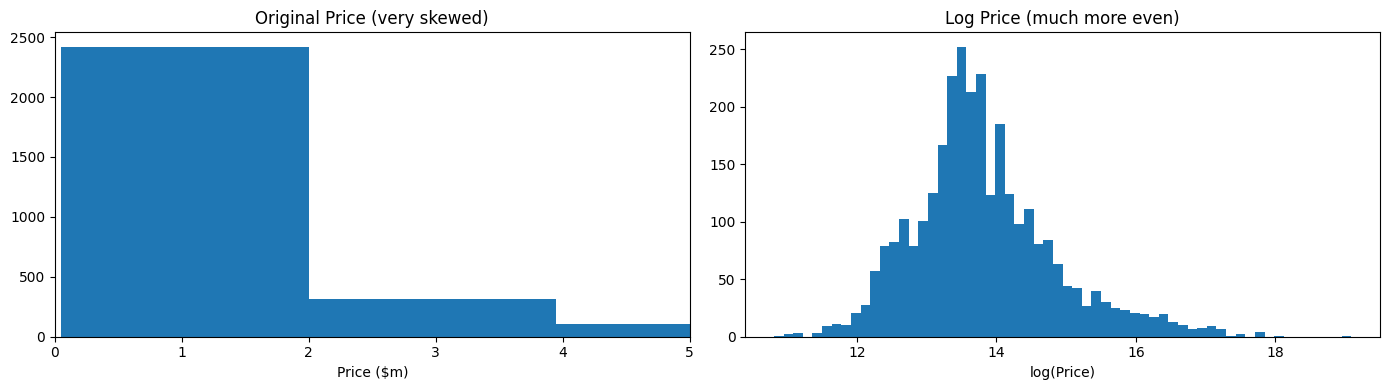

In [11]:
# Show why the log transform helps: price before and after
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.hist(data["PRICE"] / 1000000, bins=100)
plt.xlim(0, 5)
plt.title("Original Price (very skewed)")
plt.xlabel("Price ($m)")

plt.subplot(1, 2, 2)
plt.hist(data["LOG_PRICE"], bins=60)
plt.title("Log Price (much more even)")
plt.xlabel("log(Price)")

plt.tight_layout()
plt.show()

In [12]:
# --- Build the final features (X) and target (y) ---

# The number features we will use
number_features = ["BEDS", "BATH", "LOG_SQFT", "BATH_PER_BED"]

# Turn the text columns (borough, type) into 0/1 columns so the model can use them.
# drop_first=True removes one category to avoid repeating information.
borough_columns = pd.get_dummies(data["BOROUGH"], drop_first=True)
type_columns = pd.get_dummies(data["PROPERTY_TYPE"], prefix="TYPE", drop_first=True)

# Put all the features together into one table
X = pd.concat([data[number_features], borough_columns, type_columns], axis=1)
X = X.astype(float)   # make sure every column is a number

# The target is the log of price
y = data["LOG_PRICE"]

print("Features used:", list(X.columns))
X.head()

Features used: ['BEDS', 'BATH', 'LOG_SQFT', 'BATH_PER_BED', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'TYPE_Coming Soon', 'TYPE_Condo', 'TYPE_Contingent', 'TYPE_For sale', 'TYPE_Foreclosure', 'TYPE_House', 'TYPE_Land', 'TYPE_Multi-family home', 'TYPE_Pending', 'TYPE_Townhouse']


,BEDS,BATH,LOG_SQFT,BATH_PER_BED,Brooklyn,Manhattan,Queens,Staten Island,TYPE_Coming Soon,TYPE_Condo,TYPE_Contingent,TYPE_For sale,TYPE_Foreclosure,TYPE_House,TYPE_Land,TYPE_Multi-family home,TYPE_Pending,TYPE_Townhouse
0,2.0,2.000000,7.244228,1.000000,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7.0,10.000000,9.772524,1.428571,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,2.000000,7.608374,0.500000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,3.0,1.000000,6.098074,0.333333,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7.0,2.373861,9.559235,0.339123,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 4. Train the model and look at the coefficients

We split the data into a training part and a test part, standardize the features (put them
on the same scale), and then fit the multiple linear regression model.

In [13]:
# Import the tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# STEP 1: Split into training (80%) and test (20%) data.
# random_state=42 just makes the split the same every time we run it.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 2: Standardize the features (mean 0, standard deviation 1).
# We learn the scaling from the training data, then apply it to both.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 3: Create and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("The model is trained.")

The model is trained.


In [14]:
# Look at the coefficients (how much each feature affects the price)
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", round(model.intercept_, 3))
coefficients

Intercept: 13.825


,Feature,Coefficient
0,BEDS,-1.336088e-01
1,BATH,1.062262e-01
2,LOG_SQFT,7.528959e-01
3,BATH_PER_BED,-1.923593e-02
4,Brooklyn,2.243214e-01
5,Manhattan,4.977833e-01
6,Queens,1.400199e-01
7,Staten Island,3.310383e-02
8,TYPE_Coming Soon,8.326673e-17
9,TYPE_Condo,2.503518e-01


**How to read this:** the intercept is the starting point, and each coefficient shows
how that feature pushes the (log) price up (positive number) or down (negative number).
Square footage and location have the biggest effect, which makes sense for housing.

## 5. Predicting the price of a 5-bed, 5-bath, 350 sqft property

The question mentions "a particular location", and our model uses location and type, so we
pick one: a **Condo in Manhattan**.

In [15]:
# Create the new property we want to predict.
# We give the values we know; every other feature column starts at 0.
new_house = pd.DataFrame([{
    "BEDS": 5,
    "BATH": 5,
    "LOG_SQFT": np.log(350),     # remember we used the log of size
    "BATH_PER_BED": 5 / 5,       # 5 baths / 5 beds = 1
    "Manhattan": 1,              # location = Manhattan
    "TYPE_Condo": 1              # property type = Condo
}])

# Make sure it has the exact same columns as the training data (fill the rest with 0)
new_house = new_house.reindex(columns=X.columns, fill_value=0)

# Scale it the same way as the training data, then predict
new_house_scaled = scaler.transform(new_house)
predicted_log_price = model.predict(new_house_scaled)[0]

# The model predicts log price, so we use exp() to turn it back into dollars
predicted_price = np.exp(predicted_log_price)

print("Predicted price:", round(predicted_price, 2), "dollars")

Predicted price: 515002.33 dollars


**Note:** a 5-bedroom, 5-bathroom home in only 350 square feet is not physically
possible (350 sqft is the size of a studio). So this is a guess far outside the real data and
should not be taken as a real price — it just shows what the formula gives.

## 6. Two performance-evaluation tests

We test the model on the test data (data it has never seen) using two measures:
- **R² (R-squared):** how much of the price variation the model explains (closer to 1 is better).
- **RMSE:** the typical size of the error.

In [16]:
# Import the scoring tools
from sklearn.metrics import r2_score, mean_squared_error

# Predict on the test data
y_pred = model.predict(X_test_scaled)

# TEST 1: R-squared
r2 = r2_score(y_test, y_pred)
print("Test 1 - R-squared:", round(r2, 4))

# TEST 2: RMSE (root mean squared error), on the log scale
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test 2 - RMSE (log scale):", round(rmse, 4))

# Extra: show the typical error in real dollars (using the middle value, the median)
predicted_dollars = np.exp(y_pred)
actual_dollars = np.exp(y_test)
typical_error = np.median(np.abs(actual_dollars - predicted_dollars))
print("Typical error in dollars (median):", round(typical_error, 2))

Test 1 - R-squared: 0.7989
Test 2 - RMSE (log scale): 0.437
Typical error in dollars (median): 209852.05


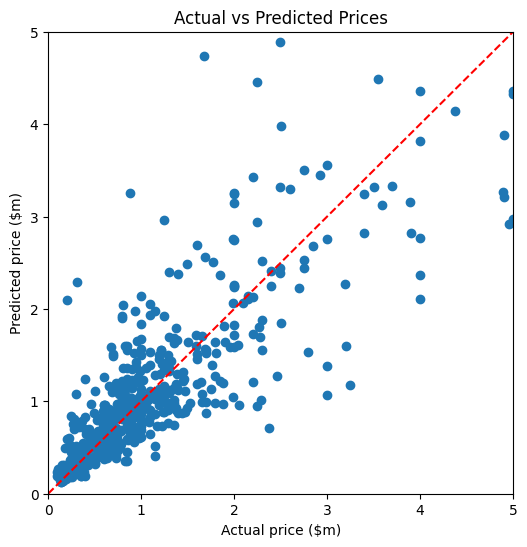

In [17]:
# Chart: actual price vs predicted price.
# If the model is good, the points sit close to the red line.
plt.figure(figsize=(6, 6))
plt.scatter(actual_dollars / 1000000, predicted_dollars / 1000000)
plt.plot([0, 5], [0, 5], "r--")   # the "perfect prediction" line
plt.xlim(0, 5); plt.ylim(0, 5)
plt.xlabel("Actual price ($m)")
plt.ylabel("Predicted price ($m)")
plt.title("Actual vs Predicted Prices")
plt.show()

### Did we make good predictions?

- **R² is about 0.80**, which means the model explains around 80% of why prices differ.
  This is a big improvement compared with using only beds, baths and square footage (~0.28).
- The biggest improvements came from using the **log of price and size**, and from adding
  **location (borough)** and **property type**.
- In the chart, the points follow the red line fairly closely, which shows the predictions
  are reasonable for most homes.

**Overall:** the model makes good predictions for normal houses. The only bad case is the
Step 5 example, because a 5-bed/5-bath home in 350 sqft cannot really exist, so the model has
to guess outside the data it learned from.